<a href="https://colab.research.google.com/github/IrsyadFHMI/PBA_2025_Citilink/blob/main/Week2_Scrapping_Apps_Review_citilink.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Scrapping Google Apps Review - eg Citilink
Week 2 NLP Pipeline PBA/ Genap 2025/ Irmasari Hafidz irma@its.ac.id

In [ ]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.3 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

In [ ]:
#Android App Mobile JKN  from Google Play at
#https://play.google.com/store/apps/details?id=app.bpjs.mobile&hl=id
#https://play.google.com/store/apps/details?id=com.jaklingkoindonesia.app&hl=id&pli=1
#https://play.google.com/store/apps/details?id=com.grabtaxi.passenger&hl=en
#https://play.google.com/store/apps/details?id=id.co.m.citilink.tras&hl=id
#The apps ID found in the link after id=app.bpjs.mobile&hl=id
#The apps name on Google Play titled: MobileJKN dari Pemerintah Indonesia (Kemenkes)
#Dated 3 March 2025 and N of reviews 787K

from google_play_scraper import app, Sort, reviews_all

grab_reviews = reviews_all(
    'id.co.m.citilink.tras',
    sleep_milliseconds=0, # defaults to 0
    lang='id', # defaults to 'en'
    sort=Sort.NEWEST, # defaults to Sort.MOST_RELEVANT
)

In [ ]:
#Save Mobile JKN reviews into dataframe
df_citilink = pd.DataFrame(np.array(grab_reviews),columns=['content'])
df_citilink = df_citilink.join(pd.DataFrame(df_citilink.pop('content').tolist()))
df_citilink.to_csv(r'df_citilink', index=False)

In [ ]:
import pandas as pd

df_citilink = pd.read_csv("df_citilink")
print(df_citilink.shape)
print(df_citilink.head())


(1878, 11)
                               reviewId                userName  \
0  48f7845e-65e1-4ad3-8cde-1ab9d1062499            Uci Agustina   
1  9b52bccb-ede5-4d0f-9b30-b866c60d8079              gemal aziz   
2  5adc355e-ceed-490f-afbc-9582d01bdfac          Raka Ilhamsyah   
3  fcd0e2fa-a1c0-4a8b-9466-53e48ea9f041  Deviana Oktadianingsih   
4  5402b7be-37c4-49ee-849d-17a39ba18b5a             Edy Sentoso   

                                           userImage  \
0  https://play-lh.googleusercontent.com/a-/ALV-U...   
1  https://play-lh.googleusercontent.com/a-/ALV-U...   
2  https://play-lh.googleusercontent.com/a/ACg8oc...   
3  https://play-lh.googleusercontent.com/a-/ALV-U...   
4  https://play-lh.googleusercontent.com/a-/ALV-U...   

                                             content  score  thumbsUpCount  \
0  Untuk masalah reschedule masih bagus traveloka...      1              0   
1  hallo Citilink, kapan ya dibuka lagi rute Meda...      4              0   
2  buruk banget

## Homework TUGAS 1A

NLP Pipeline:
RAW data (save to csv) lakukan:

* Tokenization
* Lowering
* Stopword Removal
* Lemmatization
* Stemming
* Punctuations Removal
* Expand Contractions
* Spelling Correction
* Rare Words Removal
* Common Words Removal

(save as cleandata.csv)
* Frequent words (n=50,100,1000)
* Frequent Words found (new), contoh: yg, bs, tyt
* ditambahkan di stopwords removal
* Stopwords removal (NLTK, misal case study review hanya dalam Indonesia n=758)


In [ ]:
df_citilink

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,f4363376-153f-42ad-8395-6695eb9939b2,Heri Waluyo,https://play-lh.googleusercontent.com/a/ACg8oc...,makin ke sini makin sering delay seperti maska...,1,0,9.15.2,2025-09-06 13:03:09,Selamat Malam Bapak/Ibu. Terima kasih atas ula...,2025-09-08 12:20:10,9.15.2
1,48f7845e-65e1-4ad3-8cde-1ab9d1062499,Uci Agustina,https://play-lh.googleusercontent.com/a-/ALV-U...,Untuk masalah reschedule masih bagus traveloka...,1,0,9.15.2,2025-09-05 16:47:47,Selamat Malam Bapak/Ibu. Terima kasih atas ula...,2025-09-08 12:19:44,9.15.2
2,9b52bccb-ede5-4d0f-9b30-b866c60d8079,gemal aziz,https://play-lh.googleusercontent.com/a-/ALV-U...,"hallo Citilink, kapan ya dibuka lagi rute Meda...",4,0,5.7.1,2025-09-05 08:00:03,Selamat Siang Bapak/Ibu. Terima kasih atas ula...,2025-09-09 06:42:03,5.7.1
3,5adc355e-ceed-490f-afbc-9582d01bdfac,Raka Ilhamsyah,https://play-lh.googleusercontent.com/a/ACg8oc...,buruk banget admin slowrespon sangat mengecewa...,1,0,None,2025-09-04 06:09:59,Selamat Malam Bapak/Ibu. Terima kasih atas ula...,2025-09-08 12:18:58,None
4,fcd0e2fa-a1c0-4a8b-9466-53e48ea9f041,Deviana Oktadianingsih,https://play-lh.googleusercontent.com/a-/ALV-U...,Terimakasih citilink. Senang terbang dengan ci...,5,0,9.15.0,2025-08-23 12:36:36,Selamat Siang Bapak/Ibu. Terima kasih atas ula...,2025-08-26 05:34:04,9.15.0
...,...,...,...,...,...,...,...,...,...,...,...
1873,50aff5ce-e9db-4560-b26e-b2febe6421c9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Ini aplikasi sangat membantu... Tp tolong d ke...,5,34,1.0.4,2019-11-16 14:29:35,Halo Terima kasih banyak untuk feedbacknya. Se...,2020-02-13 03:28:32,1.0.4
1874,d808eb2e-f4cb-4f8a-833a-c34545818be4,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Oke,5,3,None,2019-11-12 11:09:10,Halo Terima kasih banyak telah menggunakan apl...,2020-02-13 03:23:55,None
1875,fd0f1b3e-12b5-43bd-bc4e-bb0699f3bcb1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Good job 👍👍👍,5,3,1.0.0,2019-11-02 15:02:02,Halo Terima kasih banyak telah menggunakan apl...,2020-02-13 03:23:49,1.0.0
1876,36170f75-41fa-4c1a-acb2-e2c1d16deeda,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasinya top bgtz,5,7,1.0.0,2019-10-22 03:53:45,Halo Terima kasih banyak telah menggunakan apl...,2020-02-13 03:23:35,1.0.0


In [ ]:
df_citilink.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1878 entries, 0 to 1877
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              1878 non-null   object        
 1   userName              1878 non-null   object        
 2   userImage             1878 non-null   object        
 3   content               1878 non-null   object        
 4   score                 1878 non-null   int64         
 5   thumbsUpCount         1878 non-null   int64         
 6   reviewCreatedVersion  1528 non-null   object        
 7   at                    1878 non-null   datetime64[ns]
 8   replyContent          400 non-null    object        
 9   repliedAt             400 non-null    datetime64[ns]
 10  appVersion            1528 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 161.5+ KB


In [ ]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_citilink.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,makin ke sini makin sering delay seperti maska...,1,0,9.15.2,2025-09-06 13:03:09,Selamat Malam Bapak/Ibu. Terima kasih atas ula...,2025-09-08 12:20:10
1,Untuk masalah reschedule masih bagus traveloka...,1,0,9.15.2,2025-09-05 16:47:47,Selamat Malam Bapak/Ibu. Terima kasih atas ula...,2025-09-08 12:19:44
2,"hallo Citilink, kapan ya dibuka lagi rute Meda...",4,0,5.7.1,2025-09-05 08:00:03,Selamat Siang Bapak/Ibu. Terima kasih atas ula...,2025-09-09 06:42:03
3,buruk banget admin slowrespon sangat mengecewa...,1,0,None,2025-09-04 06:09:59,Selamat Malam Bapak/Ibu. Terima kasih atas ula...,2025-09-08 12:18:58
4,Terimakasih citilink. Senang terbang dengan ci...,5,0,9.15.0,2025-08-23 12:36:36,Selamat Siang Bapak/Ibu. Terima kasih atas ula...,2025-08-26 05:34:04
...,...,...,...,...,...,...,...
1873,Ini aplikasi sangat membantu... Tp tolong d ke...,5,34,1.0.4,2019-11-16 14:29:35,Halo Terima kasih banyak untuk feedbacknya. Se...,2020-02-13 03:28:32
1874,Oke,5,3,None,2019-11-12 11:09:10,Halo Terima kasih banyak telah menggunakan apl...,2020-02-13 03:23:55
1875,Good job 👍👍👍,5,3,1.0.0,2019-11-02 15:02:02,Halo Terima kasih banyak telah menggunakan apl...,2020-02-13 03:23:49
1876,Aplikasinya top bgtz,5,7,1.0.0,2019-10-22 03:53:45,Halo Terima kasih banyak telah menggunakan apl...,2020-02-13 03:23:35


In [ ]:
#Check number of reviews scores
df_citilink['score'].value_counts()

,count
score,
1,951
5,643
2,138
4,85
3,61


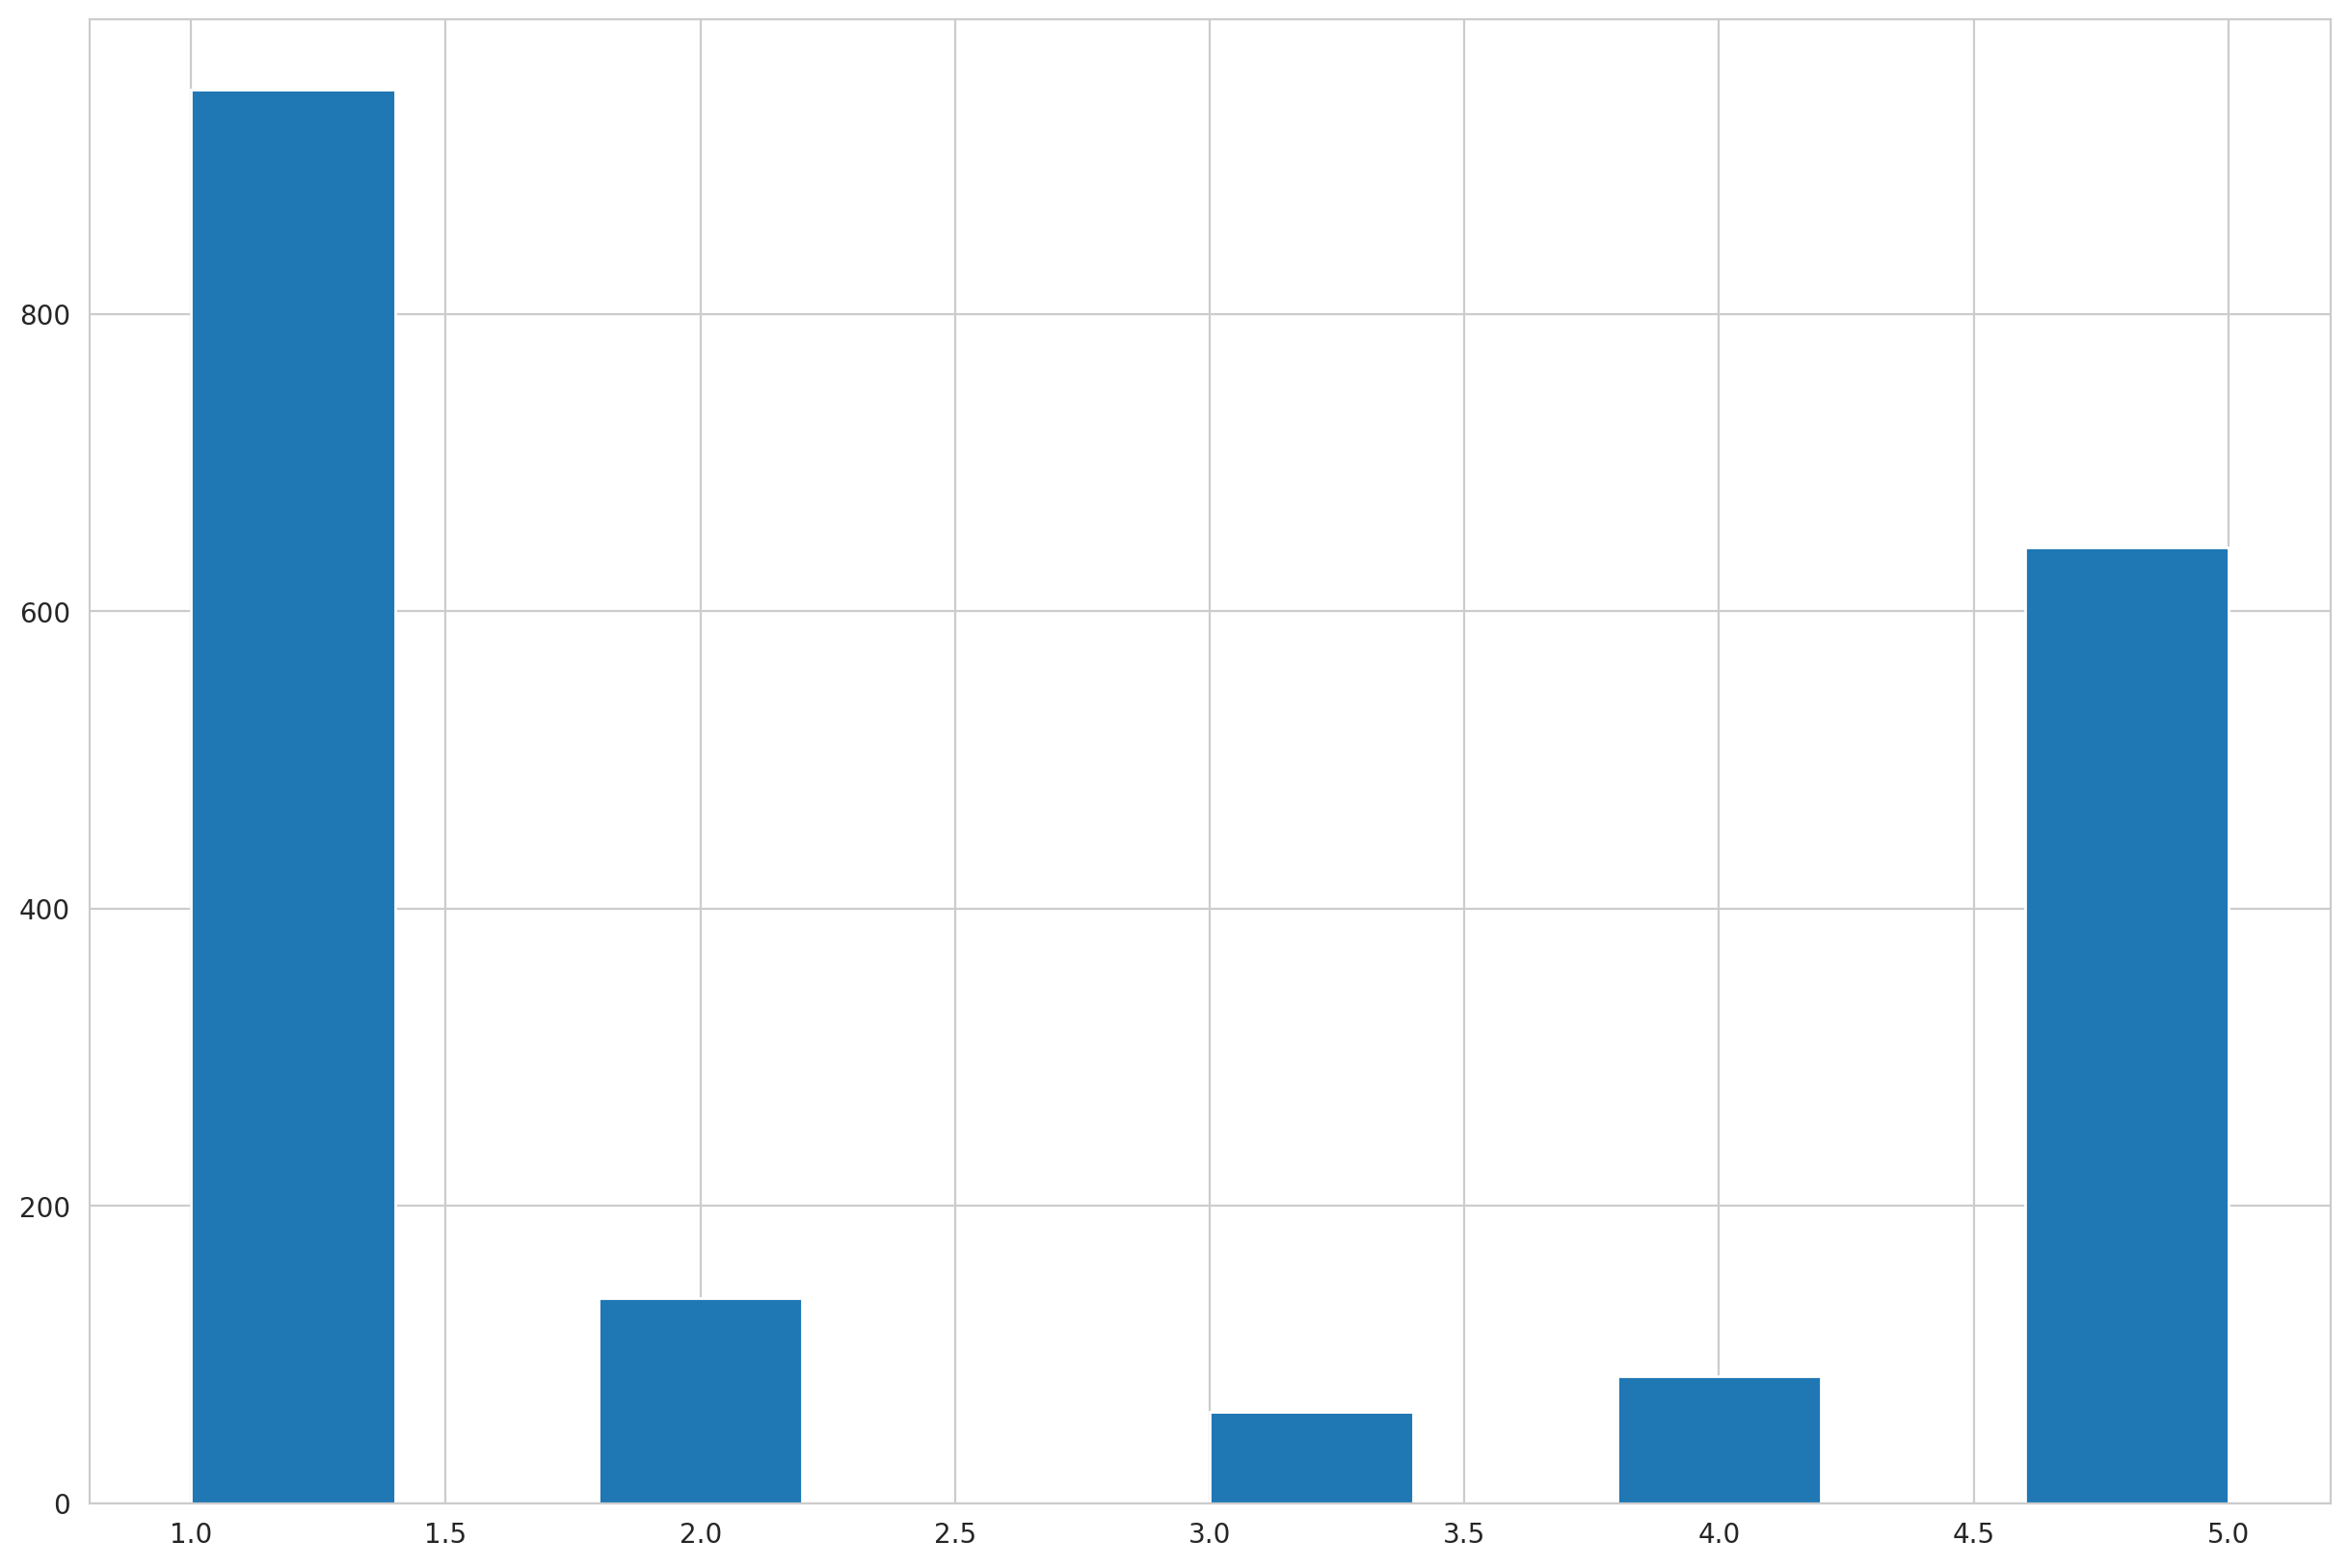

In [ ]:
plt.hist(df_citilink['score'])
plt.show()

In [ ]:
!pip install emoji

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#from pandas_profiling import ProfileReport
import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 14.8 MB/s eta 0:00:00


In [ ]:
#Creating polarity on the column: content (review from the apps) using TextBlob
#Read https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
# Handle None values in 'content' column by replacing them with empty strings
df_citilink['sentiment_polarity'] = df_citilink['content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df_citilink['sentiment_subjective'] = df_citilink['content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)

In [ ]:
df_citilink.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,makin ke sini makin sering delay seperti maskapai sebelah....yg paling JOSS sekarang PELITA AIR,1,0.0,0.0
1,"Untuk masalah reschedule masih bagus traveloka. Di app traveloka, kalau kita belum bayar, jadwalnya tidak akan berubah, tapi di app ini jadwalnya langsung di reschedule dan mau gak mau harus bayar.",1,0.0,0.0
2,"hallo Citilink, kapan ya dibuka lagi rute Medan bandung melalui bandara Husein 🙏",4,0.0,0.0
3,buruk banget admin slowrespon sangat mengecewakan ga rekomennnnn nnnn!!!!!!!!,1,0.0,0.0
4,"Terimakasih citilink. Senang terbang dengan citilink, ramah, nyaman, mendarat mulus, on time. Semua rombongan pun happy",5,0.8,1.0
...,...,...,...,...
1873,Ini aplikasi sangat membantu... Tp tolong d kembangkan untuk pembayarannya bisa lewai gerai2 seperti Alfa atau lainnya... Saya senang krn dpt diskon 20%,5,0.0,0.0
1874,Oke,5,0.0,0.0
1875,Good job 👍👍👍,5,0.7,0.6
1876,Aplikasinya top bgtz,5,0.5,0.5


## Lowercasing


In [ ]:
df_citilink['lower'] = df_citilink['content'].astype(str).str.lower()
df_citilink[['content','lower']].head()


,content,lower
0,makin ke sini makin sering delay seperti maskapai sebelah....yg paling JOSS sekarang PELITA AIR,makin ke sini makin sering delay seperti maskapai sebelah....yg paling joss sekarang pelita air
1,"Untuk masalah reschedule masih bagus traveloka. Di app traveloka, kalau kita belum bayar, jadwalnya tidak akan berubah, tapi di app ini jadwalnya langsung di reschedule dan mau gak mau harus bayar.","untuk masalah reschedule masih bagus traveloka. di app traveloka, kalau kita belum bayar, jadwalnya tidak akan berubah, tapi di app ini jadwalnya langsung di reschedule dan mau gak mau harus bayar."
2,"hallo Citilink, kapan ya dibuka lagi rute Medan bandung melalui bandara Husein 🙏","hallo citilink, kapan ya dibuka lagi rute medan bandung melalui bandara husein 🙏"
3,buruk banget admin slowrespon sangat mengecewakan ga rekomennnnn nnnn!!!!!!!!,buruk banget admin slowrespon sangat mengecewakan ga rekomennnnn nnnn!!!!!!!!
4,"Terimakasih citilink. Senang terbang dengan citilink, ramah, nyaman, mendarat mulus, on time. Semua rombongan pun happy","terimakasih citilink. senang terbang dengan citilink, ramah, nyaman, mendarat mulus, on time. semua rombongan pun happy"


## Punctuation removal

In [ ]:
def basic_clean(s: str) -> str:
    s = emoji.replace_emoji(str(s), replace=' ')
    s = re.sub(r'http\S+|www\.\S+', ' ', s)                  # URL
    s = re.sub(r'[^0-9a-zA-ZÀ-ž\s]', ' ', s)                 # non-alnum (tetap angka opsional)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df_citilink['clean_basic'] = df_citilink['lower'].apply(basic_clean)
df_citilink[['lower','clean_basic']].head()


,lower,clean_basic
0,makin ke sini makin sering delay seperti maskapai sebelah....yg paling joss sekarang pelita air,makin ke sini makin sering delay seperti maskapai sebelah yg paling joss sekarang pelita air
1,"untuk masalah reschedule masih bagus traveloka. di app traveloka, kalau kita belum bayar, jadwalnya tidak akan berubah, tapi di app ini jadwalnya langsung di reschedule dan mau gak mau harus bayar.",untuk masalah reschedule masih bagus traveloka di app traveloka kalau kita belum bayar jadwalnya tidak akan berubah tapi di app ini jadwalnya langsung di reschedule dan mau gak mau harus bayar
2,"hallo citilink, kapan ya dibuka lagi rute medan bandung melalui bandara husein 🙏",hallo citilink kapan ya dibuka lagi rute medan bandung melalui bandara husein
3,buruk banget admin slowrespon sangat mengecewakan ga rekomennnnn nnnn!!!!!!!!,buruk banget admin slowrespon sangat mengecewakan ga rekomennnnn nnnn
4,"terimakasih citilink. senang terbang dengan citilink, ramah, nyaman, mendarat mulus, on time. semua rombongan pun happy",terimakasih citilink senang terbang dengan citilink ramah nyaman mendarat mulus on time semua rombongan pun happy


## Expand Contraction




In [ ]:
import re

# batasi huruf berulang: "baaaagus" -> "baagus"
def squash_repeat(s):
    return re.sub(r'(.)\1{2,}', r'\1\1', s)

# kamus singkatan/serapan → untuk TOKEN tunggal saja
ABBR_MAP = {
    # umum
    "ga":"tidak","gak":"tidak","gk":"tidak","tdk":"tidak","tida":"tidak",
    "blm":"belum","udh":"sudah","udah":"sudah","sdh":"sudah",
    "yg":"yang","dgn":"dengan","dg":"dengan","sm":"sama","dr":"dari",
    "tp":"tapi","jd":"jadi","utk":"untuk","kl":"kalau","klo":"kalau","kalo":"kalau",
    "bgt":"banget","bnyk":"banyak","pls":"tolong","plis":"tolong","jgn":"jangan",
    "apk":"aplikasi","app":"aplikasi","cs":"customer service",
    "rekomen":"rekomendasi","recommend":"rekomendasi","rekom":"rekomendasi","rekomenn":"rekomendasi",
    "bs":"bisa","klu":"kalau","sya":"saya","sy":"saya","tgl":"tanggal","lbh":"lebih","n":"dan",
    "good":"bagus",
    "mantul":"mantap betul","mantull":"mantap betull",
    "ok":"oke","okey":"oke", "bgtz":"banget",
    # domain travel/airline
    "tkt":"tiket","rsv":"reservasi","dep":"departure","arr":"arrival",
    "refund":"pengembalian","reschedule":"ubah jadwal","checkin":"check in",
    "boarding":"boarding","ontime":"tepat waktu","delay":"tunda","cancel":"batal"
}

# pola frasa → untuk FRASA (≥ 2 kata)
PHRASE_MAP = {
    r"\bon ?time\b": "tepat waktu",
    r"\bcheck ?-?in\b": "check in",
    r"\bno ?show\b": "no show",
    r"\bopen seat\b": "kursi tersedia",
    r"\bcall center\b": "customer service",
    r"\bslow respon(se)?\b": "respon lambat",
    r"\bslow ?response\b": "respon lambat",
    r"\bfresh look\b": "tampilan bagus",
    r"\bgood ?job\b": "kerja bagus"
}

def normalize_text(text: str) -> str:
    t = squash_repeat(str(text))
    for pat, repl in PHRASE_MAP.items():
        t = re.sub(pat, repl, t)
    # lalu token mapping
    t = " ".join(ABBR_MAP.get(w, w) for w in t.split())
    return re.sub(r"\s+", " ", t).strip()

# apply
df_citilink['expanded'] = df_citilink['clean_basic'].astype(str).apply(normalize_text)
df_citilink[['clean_basic','expanded']].head()


,clean_basic,expanded
0,makin ke sini makin sering delay seperti maskapai sebelah yg paling joss sekarang pelita air,makin ke sini makin sering tunda seperti maskapai sebelah yang paling joss sekarang pelita air
1,untuk masalah reschedule masih bagus traveloka di app traveloka kalau kita belum bayar jadwalnya tidak akan berubah tapi di app ini jadwalnya langsung di reschedule dan mau gak mau harus bayar,untuk masalah ubah jadwal masih bagus traveloka di aplikasi traveloka kalau kita belum bayar jadwalnya tidak akan berubah tapi di aplikasi ini jadwalnya langsung di ubah jadwal dan mau tidak mau h...
2,hallo citilink kapan ya dibuka lagi rute medan bandung melalui bandara husein,hallo citilink kapan ya dibuka lagi rute medan bandung melalui bandara husein
3,buruk banget admin slowrespon sangat mengecewakan ga rekomennnnn nnnn,buruk banget admin slowrespon sangat mengecewakan tidak rekomendasi nn
4,terimakasih citilink senang terbang dengan citilink ramah nyaman mendarat mulus on time semua rombongan pun happy,terimakasih citilink senang terbang dengan citilink ramah nyaman mendarat mulus tepat waktu semua rombongan pun happy


## Stemming

In [ ]:
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
stemmer = StemmerFactory().create_stemmer()
df_citilink['stemmed'] = df_citilink['expanded'].apply(stemmer.stem)
df_citilink[['expanded','stemmed']].head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.7 MB/s eta 0:00:00


,expanded,stemmed
0,makin ke sini makin sering tunda seperti maskapai sebelah yang paling joss sekarang pelita air,makin ke sini makin sering tunda seperti maskapai belah yang paling joss sekarang pelita air
1,untuk masalah ubah jadwal masih bagus traveloka di aplikasi traveloka kalau kita belum bayar jadwalnya tidak akan berubah tapi di aplikasi ini jadwalnya langsung di ubah jadwal dan mau tidak mau h...,untuk masalah ubah jadwal masih bagus traveloka di aplikasi traveloka kalau kita belum bayar jadwal tidak akan ubah tapi di aplikasi ini jadwal langsung di ubah jadwal dan mau tidak mau harus bayar
2,hallo citilink kapan ya dibuka lagi rute medan bandung melalui bandara husein,hallo citilink kapan ya buka lagi rute medan bandung lalu bandara husein
3,buruk banget admin slowrespon sangat mengecewakan tidak rekomendasi nn,buruk banget admin slowrespon sangat kecewa tidak rekomendasi nn
4,terimakasih citilink senang terbang dengan citilink ramah nyaman mendarat mulus tepat waktu semua rombongan pun happy,terimakasih citilink senang terbang dengan citilink ramah nyaman darat mulus tepat waktu semua rombong pun happy


##Stopwords Removal
Indonesian Stopwords

In [ ]:
import nltk
nltk.download('stopwords')
# === STOPWORDS (patch) ===
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

indo_sw = set(stopwords.words('indonesian'))
sastrawi_sw = set(StopWordRemoverFactory().get_stop_words())

# stopwords custom
custom_sw = {'yang','nya','aja','in', "nn"}

# kata negasi/opini yang TIDAK BOLEH dihapus
PROTECT_WORDS = {
    'tidak','tak','bukan','jangan','tanpa','kurang','belum',
}

# gabungkan lalu buang kata yang dilindungi
all_stopwords = (indo_sw | sastrawi_sw | custom_sw) - PROTECT_WORDS

def remove_stopwords(text: str) -> str:
    return " ".join(w for w in str(text).split() if w not in all_stopwords)

df_citilink["no_stopwords"] = df_citilink["stemmed"].apply(remove_stopwords)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Tokenization

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')
df_citilink['tokens'] = df_citilink['no_stopwords'].apply(word_tokenize)
df_citilink[['no_stopwords','tokens']]


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,no_stopwords,tokens
0,tunda maskapai belah joss pelita air,"[tunda, maskapai, belah, joss, pelita, air]"
1,ubah jadwal bagus traveloka aplikasi traveloka belum bayar jadwal tidak ubah aplikasi jadwal langsung ubah jadwal tidak bayar,"[ubah, jadwal, bagus, traveloka, aplikasi, traveloka, belum, bayar, jadwal, tidak, ubah, aplikasi, jadwal, langsung, ubah, jadwal, tidak, bayar]"
2,hallo citilink buka rute medan bandung bandara husein,"[hallo, citilink, buka, rute, medan, bandung, bandara, husein]"
3,buruk banget admin slowrespon kecewa tidak rekomendasi,"[buruk, banget, admin, slowrespon, kecewa, tidak, rekomendasi]"
4,terimakasih citilink senang terbang citilink ramah nyaman darat mulus rombong happy,"[terimakasih, citilink, senang, terbang, citilink, ramah, nyaman, darat, mulus, rombong, happy]"
...,...,...
1873,aplikasi bantu d kembang bayar lewa gerai2 alfa senang krn dpt diskon 20,"[aplikasi, bantu, d, kembang, bayar, lewa, gerai2, alfa, senang, krn, dpt, diskon, 20]"
1874,oke,[oke]
1875,kerja bagus,"[kerja, bagus]"
1876,aplikasi top banget,"[aplikasi, top, banget]"


## Common Word Removal


In [ ]:
from collections import Counter

# hitung frekuensi token
freq = Counter(t for row in df_citilink['tokens'] for t in row)

# ambil kata yang jarang (<3 kali)
rare = {w for w, c in freq.items() if c < 3}

def filter_tokens(toks):
    return [t for t in toks if t not in rare]

df_citilink['tokens_filtered'] = df_citilink['tokens'].apply(filter_tokens)

# gabungkan lagi jadi kalimat akhir
df_citilink['final_text'] = df_citilink['tokens_filtered'].apply(lambda toks: " ".join(toks))
df_citilink['final_text'] = df_citilink['final_text'].fillna("EMPTY")

# QC: top 20 token setelah rare word removal
print(Counter(t for row in df_citilink['tokens_filtered'] for t in row).most_common(20))


In [ ]:
from collections import Counter
Counter(t for row in df_citilink['tokens_filtered'] for t in row).most_common(20)


[('tidak', 933),
 ('aplikasi', 824),
 ('citilink', 277),
 ('tiket', 274),
 ('bagus', 208),
 ('login', 175),
 ('terbang', 174),
 ('bayar', 157),
 ('banget', 117),
 ('beli', 117),
 ('susah', 100),
 ('mudah', 93),
 ('bantu', 89),
 ('layan', 89),
 ('email', 87),
 ('error', 84),
 ('pesan', 82),
 ('jadwal', 81),
 ('masuk', 79),
 ('buka', 77)]

In [ ]:
# gabungkan tokens_filtered jadi kalimat baru
df_citilink['final_text'] = df_citilink['tokens'].apply(lambda toks: " ".join(toks))

# cek hasil
df_citilink[['content','final_text']]


,content,final_text
0,makin ke sini makin sering delay seperti maskapai sebelah....yg paling JOSS sekarang PELITA AIR,tunda maskapai belah joss pelita air
1,"Untuk masalah reschedule masih bagus traveloka. Di app traveloka, kalau kita belum bayar, jadwalnya tidak akan berubah, tapi di app ini jadwalnya langsung di reschedule dan mau gak mau harus bayar.",ubah jadwal bagus traveloka aplikasi traveloka belum bayar jadwal tidak ubah aplikasi jadwal langsung ubah jadwal tidak bayar
2,"hallo Citilink, kapan ya dibuka lagi rute Medan bandung melalui bandara Husein 🙏",hallo citilink buka rute medan bandung bandara husein
3,buruk banget admin slowrespon sangat mengecewakan ga rekomennnnn nnnn!!!!!!!!,buruk banget admin slowrespon kecewa tidak rekomendasi
4,"Terimakasih citilink. Senang terbang dengan citilink, ramah, nyaman, mendarat mulus, on time. Semua rombongan pun happy",terimakasih citilink senang terbang citilink ramah nyaman darat mulus rombong happy
...,...,...
1873,Ini aplikasi sangat membantu... Tp tolong d kembangkan untuk pembayarannya bisa lewai gerai2 seperti Alfa atau lainnya... Saya senang krn dpt diskon 20%,aplikasi bantu d kembang bayar lewa gerai2 alfa senang krn dpt diskon 20
1874,Oke,oke
1875,Good job 👍👍👍,kerja bagus
1876,Aplikasinya top bgtz,aplikasi top banget


In [ ]:
# tampilkan semua baris & kolom penting
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

df_citilink[['content','final_text']]





,content,final_text
0,makin ke sini makin sering delay seperti maskapai sebelah....yg paling JOSS sekarang PELITA AIR,tunda maskapai belah joss pelita air
1,"Untuk masalah reschedule masih bagus traveloka. Di app traveloka, kalau kita belum bayar, jadwalnya tidak akan berubah, tapi di app ini jadwalnya langsung di reschedule dan mau gak mau harus bayar.",ubah jadwal bagus traveloka aplikasi traveloka belum bayar jadwal tidak ubah aplikasi jadwal langsung ubah jadwal tidak bayar
2,"hallo Citilink, kapan ya dibuka lagi rute Medan bandung melalui bandara Husein 🙏",hallo citilink buka rute medan bandung bandara husein
3,buruk banget admin slowrespon sangat mengecewakan ga rekomennnnn nnnn!!!!!!!!,buruk banget admin slowrespon kecewa tidak rekomendasi
4,"Terimakasih citilink. Senang terbang dengan citilink, ramah, nyaman, mendarat mulus, on time. Semua rombongan pun happy",terimakasih citilink senang terbang citilink ramah nyaman darat mulus rombong happy
5,cepat,cepat
6,bagus,bagus
7,mantap,mantap
8,bagus,bagus
9,kabari saya klo sudah bisa Qris ya,kabar qris


In [ ]:
from textblob import TextBlob

# pastikan tidak ada NaN
df_citilink['final_text'] = df_citilink['final_text'].fillna("")

# hitung polarity & subjectivity dari final_text
df_citilink['sentiment_polarity'] = df_citilink['final_text'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)
df_citilink['sentiment_subjective'] = df_citilink['final_text'].astype(str).apply(lambda x: TextBlob(x).sentiment.subjectivity)

# ambil kolom final_text, score, polarity, subjectivity
df_citilink[['final_text','score','sentiment_polarity','sentiment_subjective']].head(10)


,final_text,score,sentiment_polarity,sentiment_subjective
0,tunda maskapai belah joss pelita air,1,0.0,0.0
1,ubah jadwal bagus traveloka aplikasi traveloka belum bayar jadwal tidak ubah aplikasi jadwal langsung ubah jadwal tidak bayar,1,0.0,0.0
2,hallo citilink buka rute medan bandung bandara husein,4,0.0,0.0
3,buruk banget admin slowrespon kecewa tidak rekomendasi,1,0.0,0.0
4,terimakasih citilink senang terbang citilink ramah nyaman darat mulus rombong happy,5,0.8,1.0
5,cepat,5,0.0,0.0
6,bagus,5,0.0,0.0
7,mantap,5,0.0,0.0
8,bagus,5,0.0,0.0
9,kabar qris,1,0.0,0.0


In [ ]:
# distribusi score (bintang) di dataset
print(df_citilink['score'].value_counts())


score
1    951
5    643
2    139
4     85
3     61
Name: count, dtype: int64


In [ ]:
df_citilink.loc[:,["final_text","score","sentiment_polarity", "sentiment_subjective"]]

,final_text,score,sentiment_polarity,sentiment_subjective
0,tunda maskapai belah joss pelita air,1,0.000000,0.000000
1,ubah jadwal bagus traveloka traveloka belum bayar jadwal tidak ubah jadwal langsung ubah jadwal tidak bayar,1,0.000000,0.000000
2,hallo citilink buka rute medan bandung bandara husein,4,0.000000,0.000000
3,buruk banget admin slowrespon kecewa tidak rekomendasi,1,0.000000,0.000000
4,terimakasih citilink senang terbang citilink ramah nyaman darat mulus rombong happy,5,0.800000,1.000000
5,cepat,5,0.000000,0.000000
6,bagus,5,0.000000,0.000000
7,mantap,5,0.000000,0.000000
8,bagus,5,0.000000,0.000000
9,kabar qris,1,0.000000,0.000000


In [ ]:
# drop baris dengan final_text kosong/null
df_citilink = df_citilink.dropna(subset=['final_text']).reset_index(drop=True)

print("Jumlah baris setelah drop:", len(df_citilink))


Jumlah baris setelah drop: 1878


In [ ]:
# pilih kolom penting untuk disimpan
cleaned_df = df_citilink[['final_text', 'score', 'thumbsUpCount',
                          'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']]

# save ke CSV
cleaned_df.to_csv("citilink_cleandata.csv", index=False)

print("Saved → citilink_cleandata.csv | rows:", len(cleaned_df))


Saved → citilink_cleandata.csv | rows: 1879


In [ ]:
#Add a column name polarity_rating from changing the score of the review into 3 labels: Pos, Negative Neutral
df_citilink['sentiment_rating'] = df_citilink['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [ ]:
df_citilink.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,bagus,5,0.00,0.00,Positive
1,oke lah...tapi kasih promo lah,5,0.00,0.00,Positive
2,"aplikasi nya bagus, cepat dapat driver, mn ad , grab bike hemat nya lagi, yg bikin kmn mn jadi lebih murah",5,0.00,0.00,Positive
3,baik,5,0.00,0.00,Positive
4,prankkkkk,1,0.00,0.00,Negative
...,...,...,...,...,...
1675477,bagus,4,0.00,0.00,Positive
1675478,siipp,5,0.00,0.00,Positive
1675479,cool,5,0.35,0.65,Positive
1675480,hore,5,0.00,0.00,Positive


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


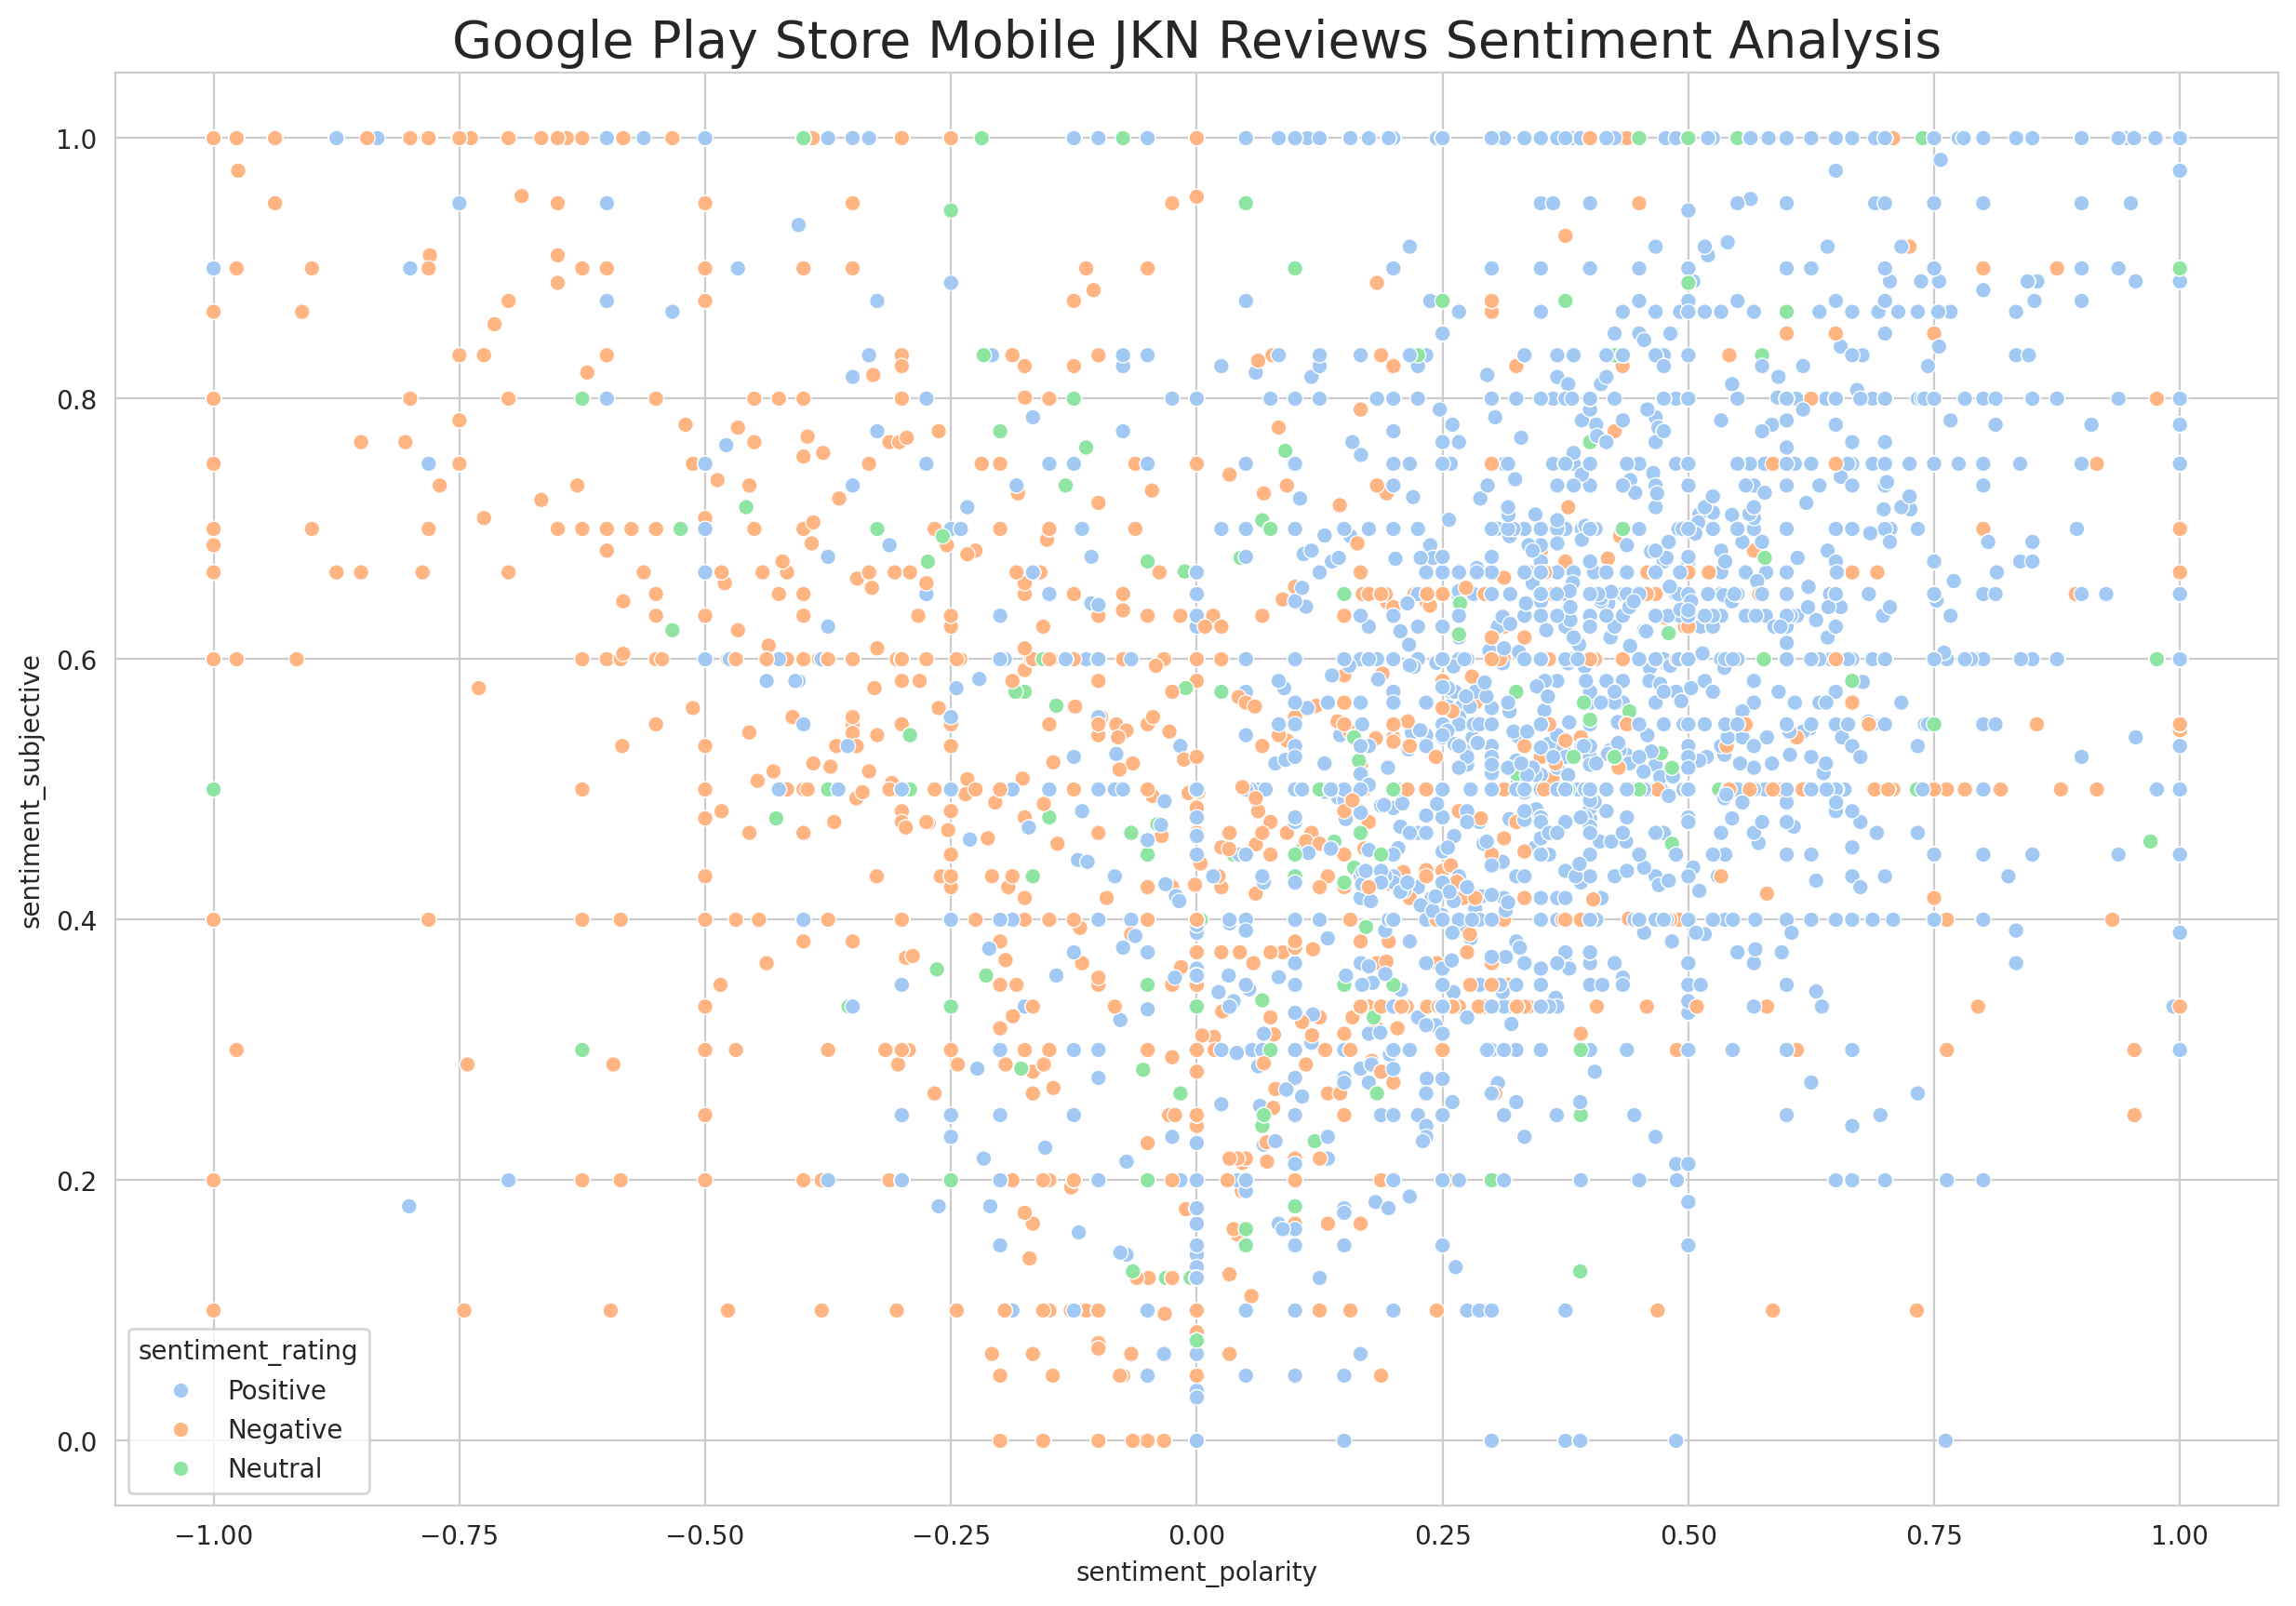

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
# Specify x and y using the 'x' and 'y' parameters within sns.scatterplot
sns.scatterplot(x=df_citilink['sentiment_polarity'], y=df_citilink['sentiment_subjective'],
                hue=df_citilink['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store Mobile JKN Reviews Sentiment Analysis", fontsize=20)
plt.show()

In [ ]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()
  #Import FreqDist from nltk.probability
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  # Use the 'rainbow' colormap for the bar plot
  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

/tmp/ipython-input-2152088084.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")


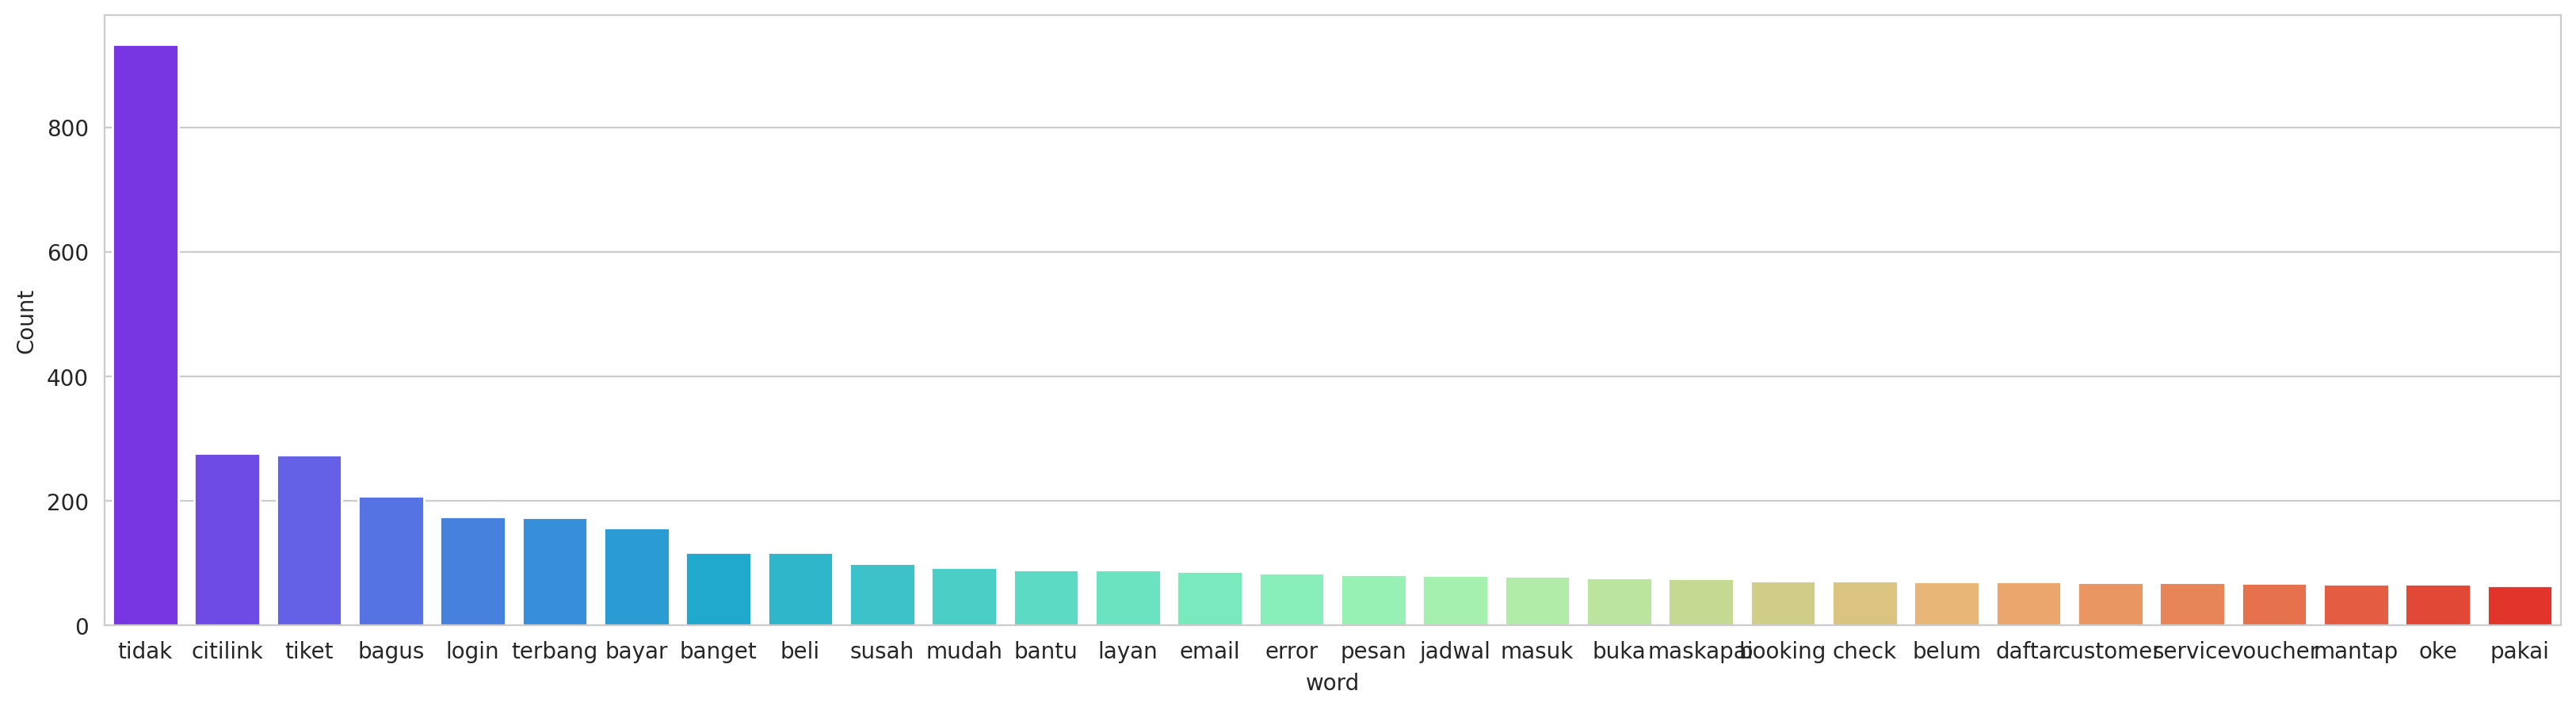

In [ ]:
freq_words(df_citilink['final_text'])

In [ ]:
# prompt: the [content] column hasnt been applied Indonesian stopwords removal using Sastrawi

!pip install Sastrawi

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Create stopword remover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Apply stopword removal to the 'content' column
df_citilink['content'] = df_citilink['content'].apply(lambda x: stopword_remover.remove(x))


## Bag of Words(BoW)

In [ ]:
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# === Step 0: Load dataset ===
df_citilink = pd.read_csv("clean_data_citilink.csv")

# pastikan kolom final_text ada
print("Kolom:", df_citilink.columns.tolist())
print(df_citilink[['final_text']].head())

# Step 1: List unique words & frekuensi
all_words = " ".join(df_citilink['final_text'].dropna().astype(str)).split()
word_frequencies = Counter(all_words)

unique_words = list(word_frequencies.keys())
print("Jumlah unique words:", len(unique_words))
print("Top 20 kata:", word_frequencies.most_common(20))

# Step 2: Buat mapping word → number
sorted_words = sorted(word_frequencies.items(), key=lambda x: x[1], reverse=True)
word_to_number = {word: i+1 for i, (word, freq) in enumerate(sorted_words)}

print("Contoh mapping 20 kata pertama:", dict(list(word_to_number.items())[:20]))

# Step 3: Manual BoW untuk 3 dokumen pertama
docs = df_citilink['final_text'].head(3).tolist()

manual_bow = []
for doc in docs:
    bow_vector = [0] * len(unique_words)
    for word in str(doc).split():
        if word in word_to_number:
            idx = word_to_number[word] - 1
            bow_vector[idx] += 1
    manual_bow.append(bow_vector)

manual_bow_df = pd.DataFrame(manual_bow, columns=unique_words)
print("Manual BoW (3 dokumen pertama):")
print(manual_bow_df.iloc[:, :15])




Kolom: ['final_text', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']
                                          final_text
0               tunda maskapai belah joss pelita air
1  ubah jadwal bagus traveloka traveloka belum ba...
2  hallo citilink buka rute medan bandung bandara...
3  buruk banget admin slowrespon kecewa tidak rek...
4  terimakasih citilink senang terbang citilink r...
Jumlah unique words: 2819
Top 20 kata: [('tidak', 933), ('citilink', 277), ('tiket', 274), ('bagus', 208), ('login', 175), ('terbang', 174), ('bayar', 157), ('banget', 117), ('beli', 117), ('susah', 100), ('mudah', 93), ('bantu', 89), ('layan', 89), ('email', 87), ('error', 84), ('pesan', 82), ('jadwal', 81), ('masuk', 79), ('buka', 77), ('maskapai', 75)]
Contoh mapping 20 kata pertama: {'tidak': 1, 'citilink': 2, 'tiket': 3, 'bagus': 4, 'login': 5, 'terbang': 6, 'bayar': 7, 'banget': 8, 'beli': 9, 'susah': 10, 'mudah': 11, 'bantu': 12, 'layan': 13, 'email': 14, 'error

In [ ]:
import numpy as np
word_freq = np.sum(X_bow, axis=0)
freq_df = pd.DataFrame({"word": feature_names, "count": word_freq})
print(freq_df.sort_values(by="count", ascending=False).head(20))


          word  count
1884     tidak    933
64    aplikasi    824
214   citilink    277
1886     tiket    274
85       bagus    208
1063     login    175
1870   terbang    174
110      bayar    157
116       beli    117
95      banget    117
1838     susah     99
1250     mudah     92
1013     layan     89
100      bantu     89
437      email     87
454      error     84
1525     pesan     82
737     jadwal     81
1155     masuk     79
177       buka     77


## EDA

/tmp/ipython-input-3635472949.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=score_counts.index, y=score_counts.values, palette='viridis')


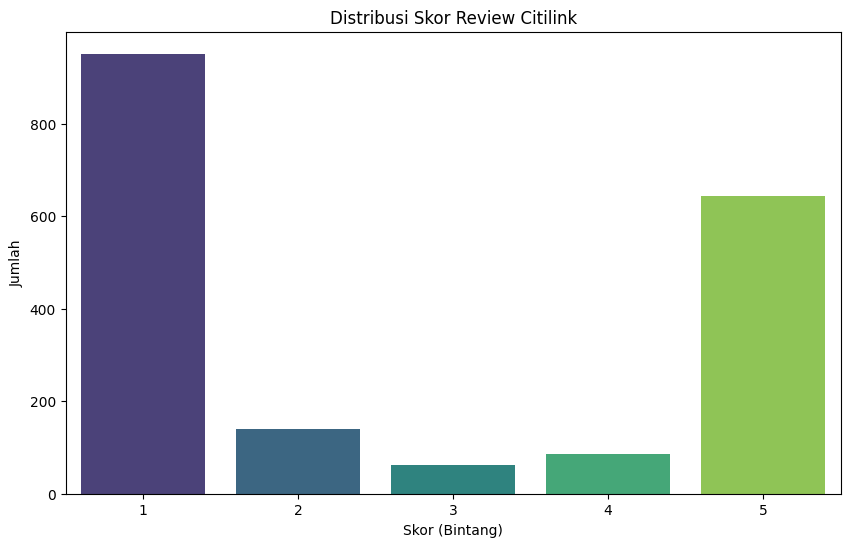

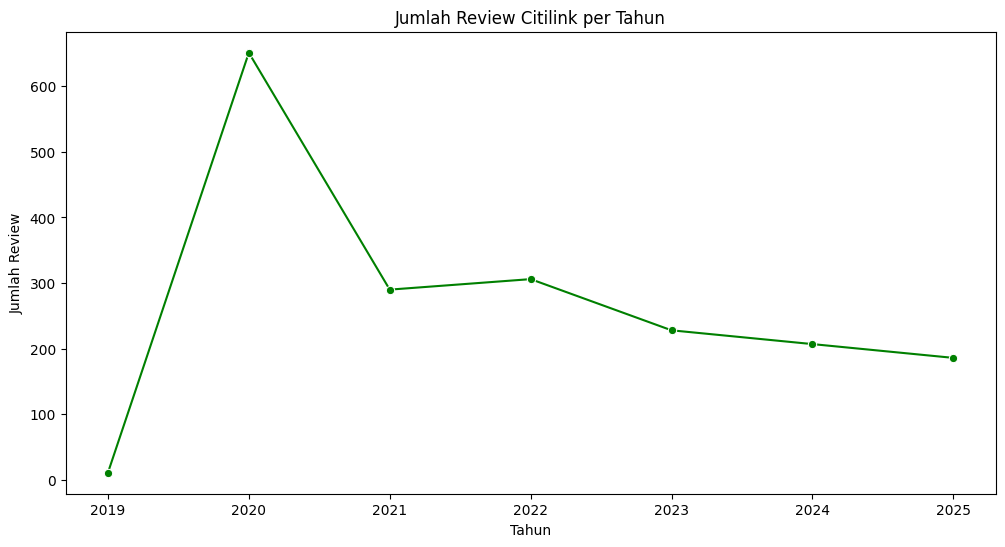

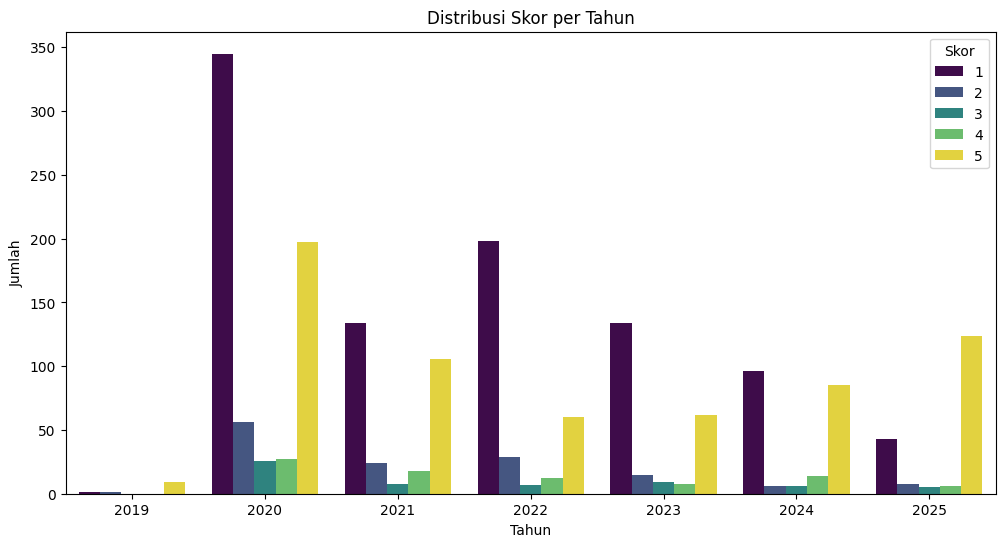

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


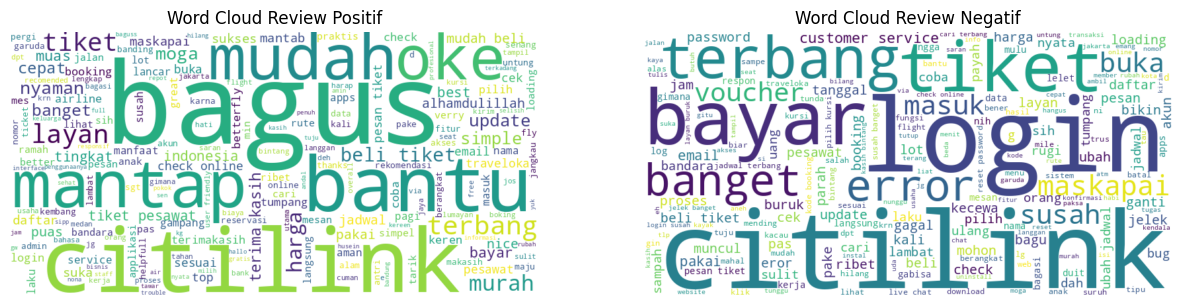

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from collections import Counter

# --- Load dataset ---
df_citilink = pd.read_csv("clean_data_citilink.csv")

# --- Pastikan kolom waktu ada dalam format datetime ---
df_citilink['at'] = pd.to_datetime(df_citilink['at'], errors='coerce')

# ========================
# 1. Distribusi Score
# ========================
score_counts = df_citilink['score'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=score_counts.index, y=score_counts.values, palette='viridis')
plt.title('Distribusi Skor Review Citilink')
plt.xlabel('Skor (Bintang)')
plt.ylabel('Jumlah')
plt.show()

# ========================
# 2. Distribusi Review per Tahun
# ========================
df_citilink['year'] = df_citilink['at'].dt.year
year_counts = df_citilink['year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='green')
plt.title('Jumlah Review Citilink per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Review')
plt.show()

# ========================
# 3. Cross tab Score vs Tahun
# ========================
plt.figure(figsize=(12, 6))
sns.countplot(x='year', hue='score', data=df_citilink, palette='viridis')
plt.title('Distribusi Skor per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah')
plt.legend(title='Skor')
plt.show()

# ========================
# 4. Wordcloud Positif vs Negatif
# ========================
# Download stopwords Indo
nltk.download('stopwords')
stop_words = set(stopwords.words('indonesian'))

# Fungsi buang stopwords
def remove_stopwords(text):
    words = str(text).split()
    filtered_words = [w for w in words if w.lower() not in stop_words]
    return ' '.join(filtered_words)

# Filter review
positive_reviews = df_citilink[df_citilink['score'] >= 4]['final_text'].dropna()
negative_reviews = df_citilink[df_citilink['score'] <= 2]['final_text'].dropna()

# Gabung & bersihkan
positive_text = remove_stopwords(" ".join(positive_reviews))
negative_text = remove_stopwords(" ".join(negative_reviews))

# Generate wordcloud
positive_wc = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
negative_wc = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
plt.imshow(positive_wc, interpolation='bilinear')
plt.title("Word Cloud Review Positif")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(negative_wc, interpolation='bilinear')
plt.title("Word Cloud Review Negatif")
plt.axis("off")
plt.show()


## TF-IDF


=== Logistic Regression (Binary) ===
Accuracy: 0.8928571428571429
Classification Report:
               precision    recall  f1-score   support

    Negative       0.86      0.99      0.92       218
    Positive       0.97      0.75      0.85       146

    accuracy                           0.89       364
   macro avg       0.92      0.87      0.88       364
weighted avg       0.90      0.89      0.89       364

Confusion Matrix:
 [[215   3]
 [ 36 110]]

=== XGBoost (Binary) ===


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:12:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9065934065934066
Classification Report:
               precision    recall  f1-score   support

    Negative       0.93      0.91      0.92       218
    Positive       0.87      0.90      0.89       146

    accuracy                           0.91       364
   macro avg       0.90      0.91      0.90       364
weighted avg       0.91      0.91      0.91       364

Confusion Matrix:
 [[198  20]
 [ 14 132]]


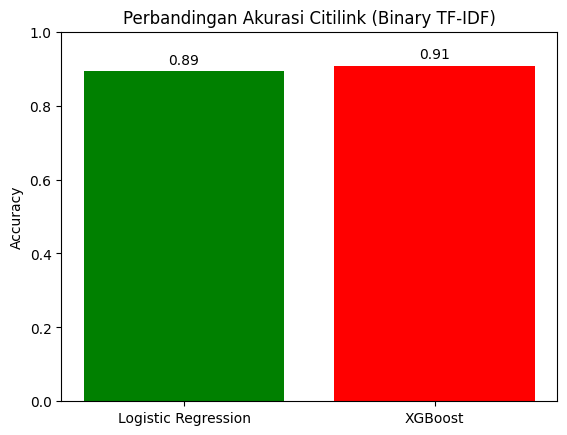

In [ ]:
# ========================================
# Logistic Regression & XGBoost (Binary) untuk Citilink
# ========================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# --- 1. Load Data ---
df = pd.read_csv("clean_data_citilink.csv")

# Ambil hanya Positive & Negative
df_bin = df[df['score'] != 3].copy()

# Fitur & Label
X = df_bin['final_text'].astype(str)
y = df_bin['score'].apply(lambda x: 'Positive' if x > 3 else 'Negative')

# Encode label jadi numerik
le = LabelEncoder()
y_encoded = le.fit_transform(y)   # Negative=0, Positive=1

# --- 2. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- 3. TF-IDF ---
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# --- 4. Logistic Regression ---
print("\n=== Logistic Regression (Binary) ===")
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr, target_names=le.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

# --- 5. XGBoost ---
print("\n=== XGBoost (Binary) ===")
xgb = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42)
xgb.fit(X_train_tfidf, y_train)
y_pred_xgb = xgb.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb, target_names=le.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

# --- 6. Visualisasi ---
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

plt.bar(["Logistic Regression", "XGBoost"], [acc_lr, acc_xgb], color=['green','red'])
plt.ylabel("Accuracy")
plt.title("Perbandingan Akurasi Citilink (Binary TF-IDF)")
for i, acc in enumerate([acc_lr, acc_xgb]):
    plt.text(i, acc+0.02, f"{acc:.2f}", ha='center')
plt.ylim(0,1)
plt.show()


## NER (Named Entity Recognition)

In [ ]:
# ========================================
# Named Entity Recognition (NER) Citilink Reviews
# ========================================

import spacy
import pandas as pd

# --- 1. Load Data ---
df = pd.read_csv("clean_data_citilink.csv")

# Ambil beberapa review untuk contoh
sample_reviews = df['final_text'].dropna().astype(str).sample(10, random_state=42).tolist()

# --- 2. Load spaCy Multilingual Model ---
# Model kecil yang support banyak bahasa termasuk Indonesia
!python -m spacy download xx_ent_wiki_sm
nlp = spacy.load("xx_ent_wiki_sm")

# --- 3. Jalankan NER ---
for i, text in enumerate(sample_reviews, 1):
    doc = nlp(text)
    print(f"\nReview {i}: {text}")
    print("Entities:")
    for ent in doc.ents:
        print(f" - {ent.text} ({ent.label_})")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 100.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('xx_ent_wiki_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

Review 1: apl uda instal nggk masuk
Entities:
 - apl (MISC)

Review 2: oke
Entities:
 - oke (ORG)

Review 3: thks hope help bagus
Entities:
 - thks hope (PER)

Review 4: sampah bikin susah org compalin chat website tidak balas tlp tidak angkat
Entities:
 - sampah bikin (PER)

Review 5: tidak log password bener gw ngalah reset password nyata reset password tidak log jg
Entities:
 - tidak log (MISC)

Review 6: performa rentan error login akun gagal email pw appnya terima kasih
Entities:
 - performa rentan (MISC)
 - login akun (PER)

Review 7: bagus
Entities:
 - bagus (PER)

Rev